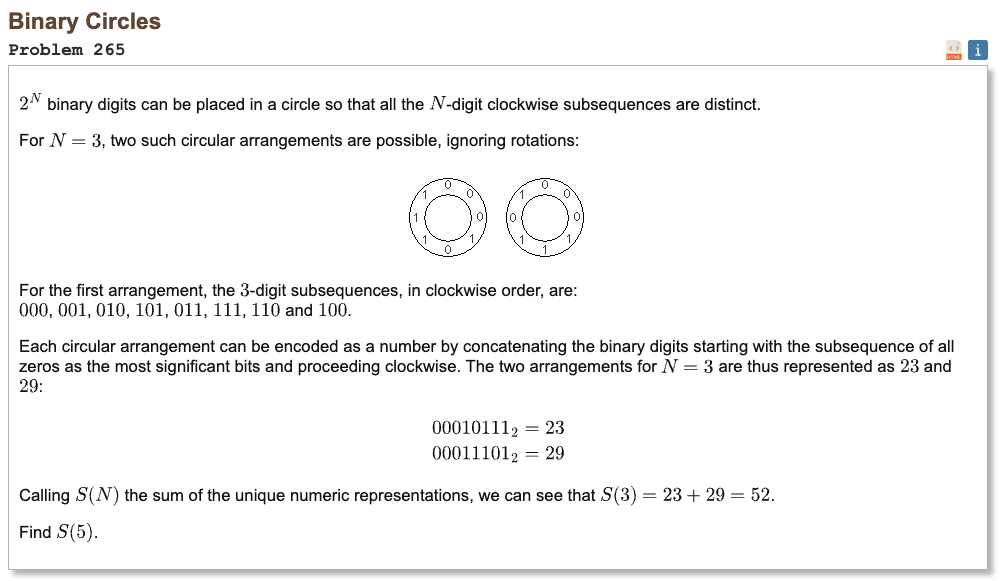

## Initial approach

* This is exactly the “de Bruijn circle” idea: a circular binary string where every length n binary block appears once.
* Build a directed graph where each node is an (n-1)-bit value, and each edge appends a 0 or 1, which creates one n-bit block.
* Every valid circle is an Eulerian cycle in this graph, because it uses every edge exactly once.
* Generate all Eulerian cycles starting from the all-zero node, convert each cycle into the circle digits, rotate so it starts with n zeros, and turn it into an integer.
* Put these integers into a set to remove duplicates, then sum them to get S(5).

In [1]:
import math

def encode_circle(bits, n):
    m = n - 1
    circle_len = 1 << n
    seq = [0] * m + bits
    circle = seq[:circle_len]
    doubled = circle + circle
    start = -1
    for i in range(circle_len):
        ok = True
        for j in range(n):
            if doubled[i + j] != 0:
                ok = False
                break
        if ok:
            start = i
            break
    if start < 0:
        return None
    rotated = doubled[start:start + circle_len]
    value = 0
    for b in rotated:
        value = (value << 1) | b
    return value

def sum_unique_representations(n):
    m = n - 1
    node_count = 1 << m
    edge_count = 1 << n

    used = [0] * node_count
    bits = [0] * edge_count
    start_node = 0
    results = set()

    def dfs(pos, node):
        if pos == edge_count:
            if node == start_node:
                value = encode_circle(bits, n)
                if value is not None:
                    results.add(value)
            return
        for bit in (0, 1):
            mask = 1 << bit
            if used[node] & mask:
                continue
            used[node] |= mask
            bits[pos] = bit
            next_node = ((node << 1) & (node_count - 1)) | bit
            dfs(pos + 1, next_node)
            used[node] ^= mask

    dfs(0, start_node)
    return sum(results)

In [2]:
%%time
print(sum_unique_representations(5))

209110240768
CPU times: user 69 ms, sys: 1.51 ms, total: 70.5 ms
Wall time: 69.5 ms
